In [1]:
import dill

data = {}
for i in range(10):
    with open(fr"E:\PhD\Jon\Artemis\Results\GIII_sim_{i}_result_lfchi.pkl", "rb") as file:
        data[i] = dill.load(file)

In [2]:
data[0].keys()

dict_keys(['par', 'Pbins', 'Qbins', 'chi2grid', 'Pa', 'Qa', 'P', 'P_err', 'Q', 'Q_err', 'zbin', 'delta', 'delta_err', 'den_var', 'lf_bins', 'phi', 'phi_err', 'Mbin', 'Mhist', 'whist', 'ev_fit_chisq', 'ev_fit_nu'])

In [3]:
for i in range(10):
    print(data[i]['P'], data[i]['Q'], data[i]['ev_fit_chisq'], data[i]['ev_fit_nu'])

1.05 0.9750000000000001 5.183333794804804 76
0.7289062500000001 1.0817187500000003 8.50515324251539 76
0.5650390625000001 1.1584765625000002 7.77701690994971 76
0.9759765625000002 1.0105859375 7.670470443310883 76
0.9759765625000002 1.0105859375 11.095017327325497 76
0.7734375000000001 1.1109375 8.601395671914688 76
0.7875000000000001 1.0750000000000002 11.270621753584734 76
0.75 1.0750000000000002 9.896143237102624 76
0.5654687500000001 1.16765625 6.112608170287796 76
0.36093749999999997 1.2096875 12.083756498465068 76


In [4]:
from lf_utils import calc_err_chi2grid
for i in range(10):
    print(i)
    calc_err_chi2grid(data[i], update_dict=False)

0
P 1.05 +/- 0.20
Q 0.98 +/- 0.08
P + Q 2.03 +/- 0.04
1
P 0.73 +/- 0.15
Q 1.08 +/- 0.05
P + Q 1.81 +/- 0.04
2
P 0.57 +/- 0.15
Q 1.16 +/- 0.05
P + Q 1.72 +/- 0.04
3
P 0.98 +/- 0.20
Q 1.01 +/- 0.07
P + Q 1.99 +/- 0.04
4
P 0.98 +/- 0.20
Q 1.01 +/- 0.07
P + Q 1.99 +/- 0.04
5
P 0.77 +/- 0.20
Q 1.11 +/- 0.07
P + Q 1.88 +/- 0.04
6
P 0.79 +/- 0.20
Q 1.08 +/- 0.08
P + Q 1.86 +/- 0.04
7
P 0.75 +/- 0.20
Q 1.08 +/- 0.08
P + Q 1.83 +/- 0.04
8
P 0.57 +/- 0.20
Q 1.17 +/- 0.07
P + Q 1.73 +/- 0.04
9
P 0.36 +/- 0.20
Q 1.21 +/- 0.08
P + Q 1.57 +/- 0.04


C:\Users\adrie\AppData\Local\Temp\ipykernel_18044\1804110189.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


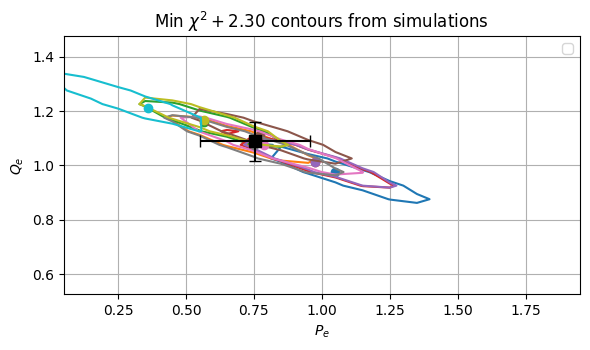

In [5]:
import dill
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle

# Load all four result files
data = {}
for i in range(10):
    with open(fr"E:\PhD\Jon\Artemis\Results\GIII_sim_{i}_result_lfchi.pkl", "rb") as file:
        data[i] = dill.load(file)

# Initialize figure
plt.figure(figsize=(6, 6))
color_cycler = cycle(plt.rcParams['axes.prop_cycle'].by_key()['color'])

P_values, Q_values = [], []

for i, d in data.items():
    color = next(color_cycler)
    contour_level = d['ev_fit_chisq'] + 2.30
    plt.contour(d['Pa'], d['Qa'], d['chi2grid'], levels=[contour_level], colors=[color])
    plt.plot(d['P'], d['Q'], 'o', color=color)
    P_values.append(d['P'])
    Q_values.append(d['Q'])

# Compute mean and std
P_mean, Q_mean = np.mean(P_values), np.mean(Q_values)
P_std, Q_std = np.std(P_values), np.std(Q_values)

# Add mean marker with error bars
plt.errorbar(P_mean, Q_mean, xerr=P_std, yerr=Q_std, fmt='ks', markersize=8, capsize=4)

# Label axes and style
plt.xlabel(r"$P_e$")
plt.ylabel(r"$Q_e$")
plt.title(r"Min $\chi^2 + 2.30$ contours from simulations")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

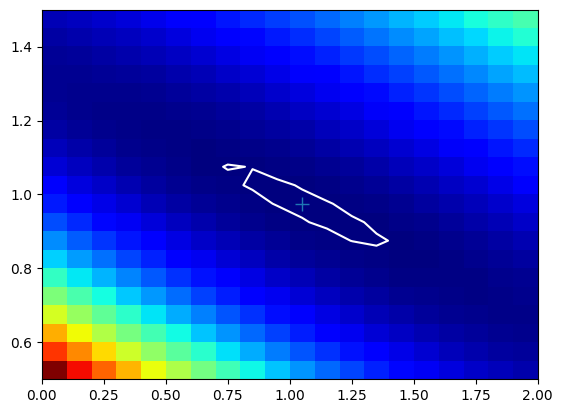

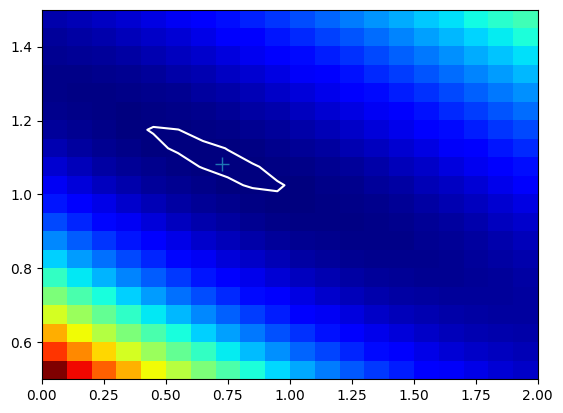

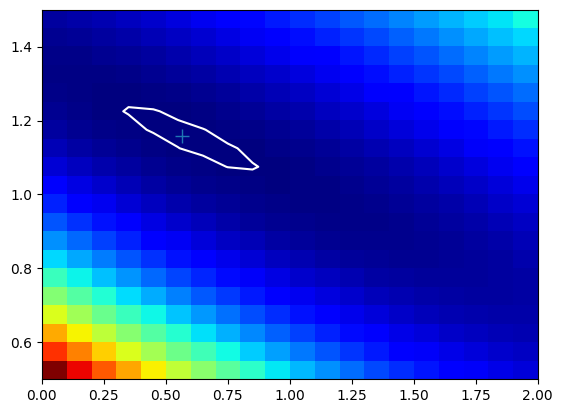

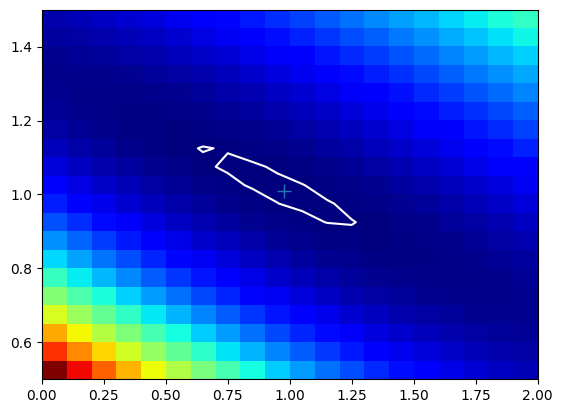

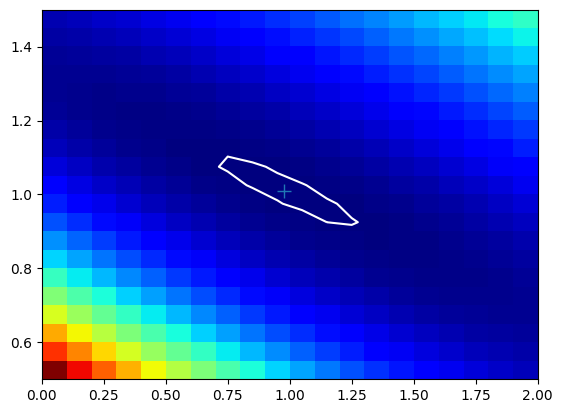

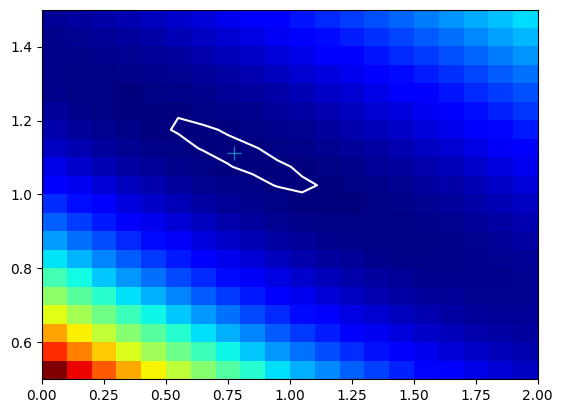

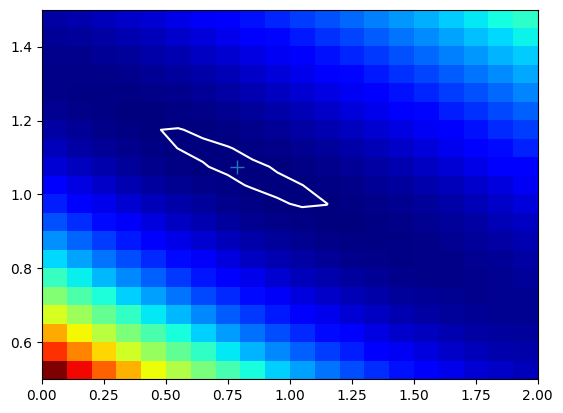

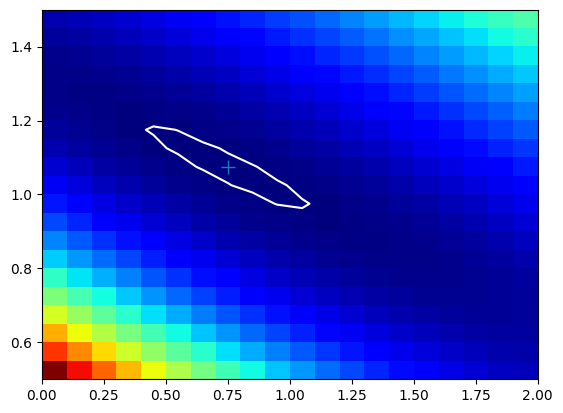

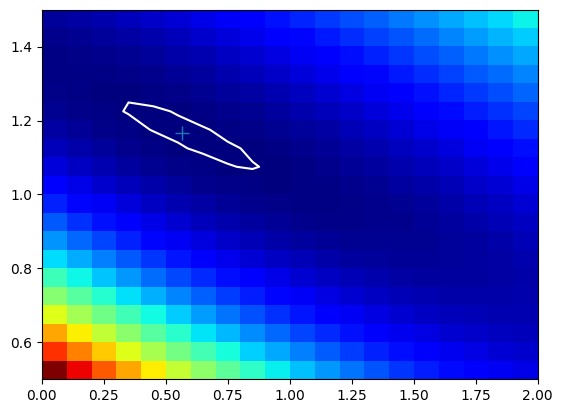

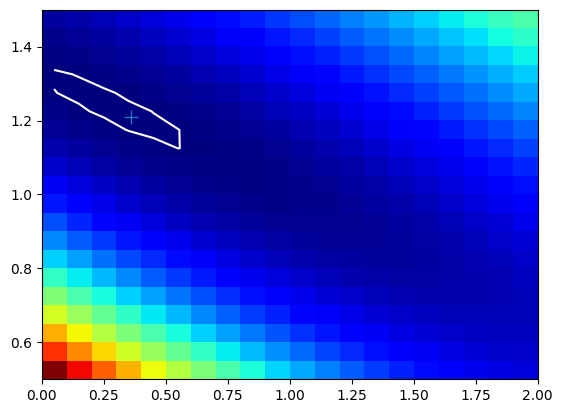

In [6]:
import matplotlib.pyplot as plt
import matplotlib

data = {}
for i in range(10):
    with open(fr"E:\PhD\Jon\Artemis\Results\GIII_sim_{i}_result_lfchi.pkl", "rb") as file:
        data[i] = dill.load(file)

for i in range(10):
    extent = (0, 2.0, 0.5, 1.5)
    cmap = matplotlib.cm.jet
    plt.imshow(data[i]['chi2grid'], cmap=cmap, aspect='auto', origin='lower', extent=extent, interpolation='nearest')
    plt.plot(data[i]['P'], data[i]['Q'], '+', markersize=10)
    contour_level = data[i]['ev_fit_chisq'] + 2.30
    plt.contour(data[i]['Pa'], data[i]['Qa'], data[i]['chi2grid'], levels=[contour_level], colors='white')
    
    plt.show()

In [7]:
import dill

data = {}
for i in range(10):
    with open(fr"E:\PhD\Jon\Artemis\Results\GIII_sim_{i}_result_post.pkl", "rb") as file:
        data[i] = dill.load(file)

In [8]:
for i in range(10):
    print(data[i]['P'], data[i]['Q'], data[i]['ev_fit_chisq'], data[i]['ev_fit_nu'])

1.05 0.9750000000000001 26.85181317225905 169368
1.05 0.9750000000000001 27.5517745281934 169318
0.9500000000000001 1.025 28.17381094078839 169454
0.9500000000000001 1.025 30.12915400242237 169449
0.9500000000000001 1.025 26.29655944967271 169510
1.1877343750000002 0.9719531250000001 26.52792450299211 169453
1.05 0.9750000000000001 30.579049577907213 169323
1.1500000000000001 0.925 27.641162817730926 169557
0.9500000000000001 1.025 26.62319910495741 169500
1.25 0.875 27.30464883809129 169192


In [9]:
from lf_utils import calc_err_chi2grid
for i in range(10):
    print(i)
    calc_err_chi2grid(data[i], update_dict=False)

0
P 1.05 +/- 0.40
Q 0.98 +/- 0.15
P + Q 2.03 +/- 0.05
1
P 1.05 +/- 0.40
Q 0.98 +/- 0.15
P + Q 2.03 +/- 0.04
2
P 0.95 +/- 0.40
Q 1.02 +/- 0.15
P + Q 1.98 +/- 0.05
3
P 0.95 +/- 0.40
Q 1.02 +/- 0.15
P + Q 1.98 +/- 0.05
4
P 0.95 +/- 0.40
Q 1.02 +/- 0.15
P + Q 1.98 +/- 0.05
5
P 1.19 +/- 0.40
Q 0.97 +/- 0.15
P + Q 2.16 +/- 0.05
6
P 1.05 +/- 0.40
Q 0.98 +/- 0.15
P + Q 2.03 +/- 0.05
7
P 1.15 +/- 0.40
Q 0.93 +/- 0.15
P + Q 2.08 +/- 0.05
8
P 0.95 +/- 0.40
Q 1.02 +/- 0.15
P + Q 1.98 +/- 0.05
9
P 1.25 +/- 0.40
Q 0.88 +/- 0.15
P + Q 2.12 +/- 0.05


C:\Users\adrie\AppData\Local\Temp\ipykernel_18044\456139688.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


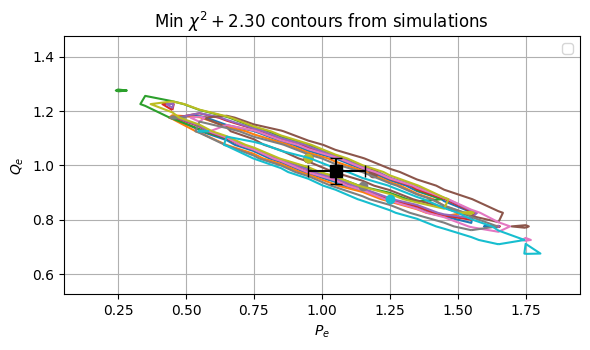

In [10]:
import dill
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle

# Load all four result files
data = {}
for i in range(10):
    with open(fr"E:\PhD\Jon\Artemis\Results\GIII_sim_{i}_result_post.pkl", "rb") as file:
        data[i] = dill.load(file)

# Initialize figure
plt.figure(figsize=(6, 6))
color_cycler = cycle(plt.rcParams['axes.prop_cycle'].by_key()['color'])

P_values, Q_values = [], []

for i, d in data.items():
    color = next(color_cycler)
    contour_level = d['ev_fit_chisq'] + 2.30
    plt.contour(d['Pa'], d['Qa'], d['chi2grid'], levels=[contour_level], colors=[color])
    plt.plot(d['P'], d['Q'], 'o', color=color)
    P_values.append(d['P'])
    Q_values.append(d['Q'])

# Compute mean and std
P_mean, Q_mean = np.mean(P_values), np.mean(Q_values)
P_std, Q_std = np.std(P_values), np.std(Q_values)

# Add mean marker with error bars
plt.errorbar(P_mean, Q_mean, xerr=P_std, yerr=Q_std, fmt='ks', markersize=8, capsize=4)

# Label axes and style
plt.xlabel(r"$P_e$")
plt.ylabel(r"$Q_e$")
plt.title(r"Min $\chi^2 + 2.30$ contours from simulations")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

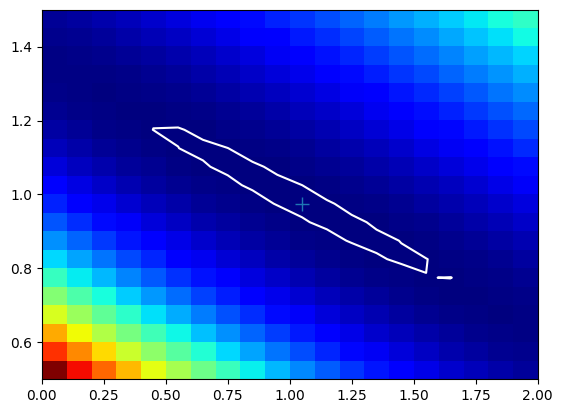

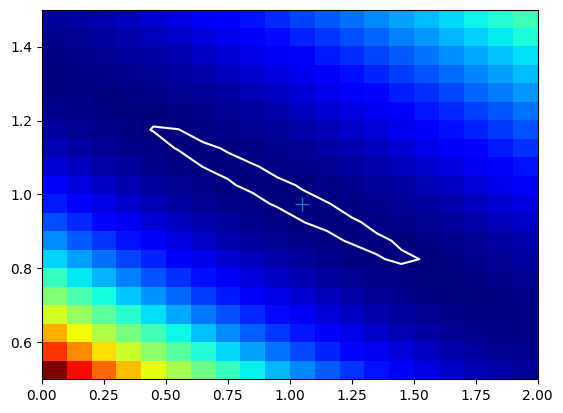

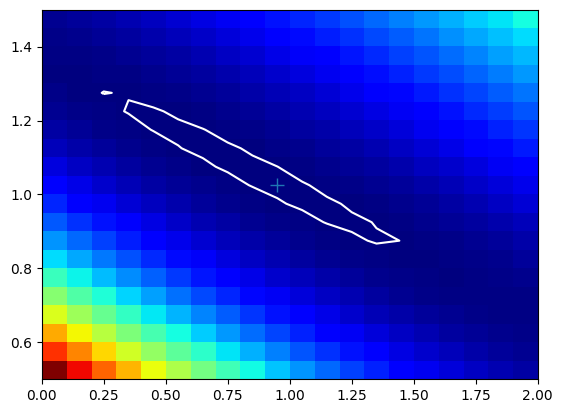

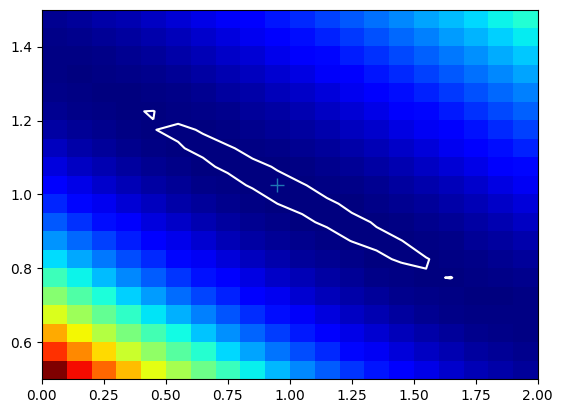

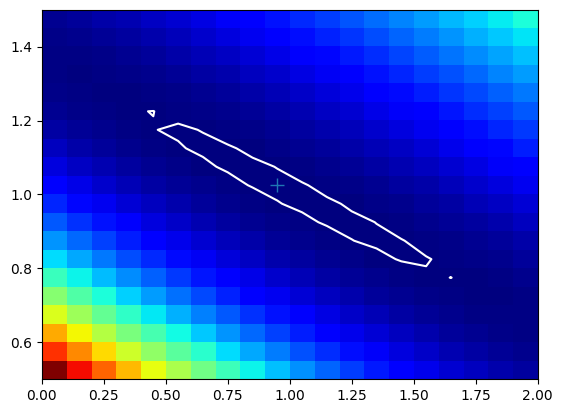

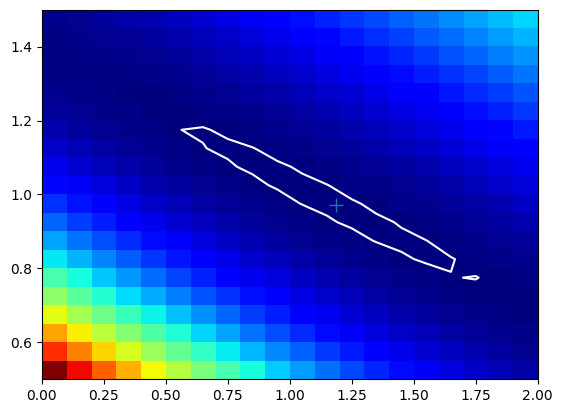

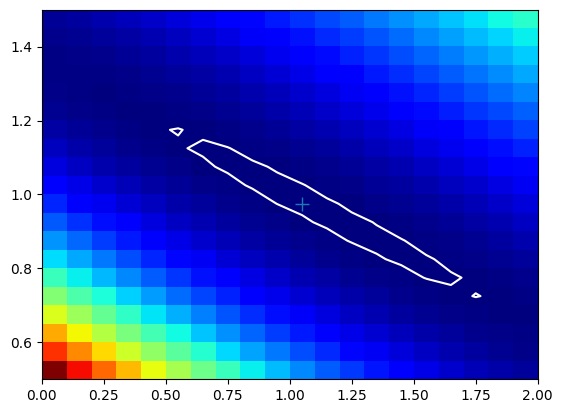

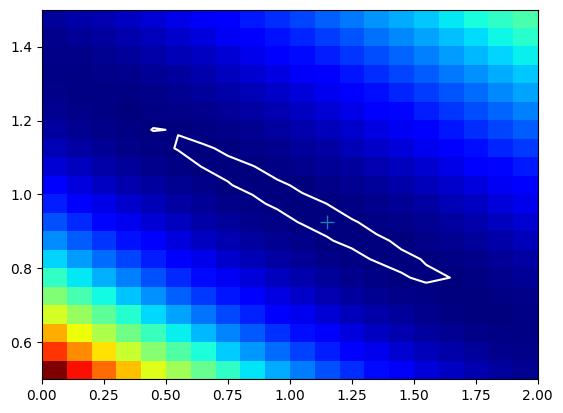

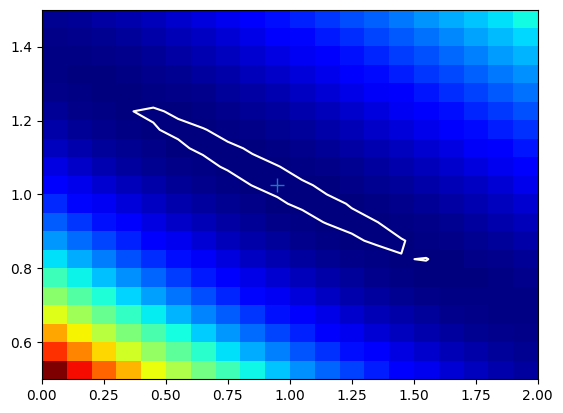

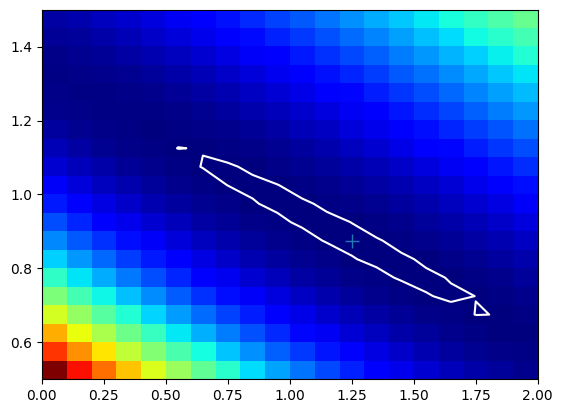

In [11]:
import matplotlib.pyplot as plt
import matplotlib

data = {}
for i in range(10):
    with open(fr"E:\PhD\Jon\Artemis\Results\GIII_sim_{i}_result_post.pkl", "rb") as file:
        data[i] = dill.load(file)

for i in range(10):
    extent = (0, 2.0, 0.5, 1.5)
    cmap = matplotlib.cm.jet
    plt.imshow(data[i]['chi2grid'], cmap=cmap, aspect='auto', origin='lower', extent=extent, interpolation='nearest')
    plt.plot(data[i]['P'], data[i]['Q'], '+', markersize=10)
    contour_level = data[i]['ev_fit_chisq'] + 2.30
    plt.contour(data[i]['Pa'], data[i]['Qa'], data[i]['chi2grid'], levels=[contour_level], colors='white')
    
    plt.show()